# Filtering and Parameter Estimation in Nonlinear State Space Models 

This python notebook investigates the Vicsek-Kuramoto model and runs the EKF on the VKSSM. Some extra plots of RMSE and interactions are added at the end.

## Vicsek - Kuramoto simulator 

In this simulation each agent lives on two dimensional torus. Since each each agent takes positions on $[0,L) \times [0,L)$.

In [16]:
"""
Vicsek–Kuramoto simulator

Simulates the discrete-time VK model:
    r_{t+1} = r_t + v Δt [cos θ_{t+1}, sin θ_{t+1}] 
    θ_{t+1} = θ_t + β Δt * Σ_j w_ij(t) sin(θ_j - θ_i) + σ sqrt(Δt) ε_t 
    

Records:
- micro states for ALL agents: headings θ[t, i] and positions r[t, i, :]
- true mean direction vector m_true[t] = (1/N) Σ_i [cos θ, sin θ]
"""

from __future__ import annotations
import numpy as np
from dataclasses import dataclass
from typing import Optional, Dict, Any, Tuple

# Parameters for the Vicsek–Kuramoto simulation
@dataclass
class SimParams:
    N: int = 50
    T: int = 500               # number of time steps to simulate
    L: float = 10.0            # box side length (periodic domain [0,L)^2)
    R: float = 1.0             # interaction radius
    v: float = 0.2             # speed
    dt: float = 0.1            # time step
    kappa: float = 3.0          # alignment strength
    sigma: float = 0.2         # heading noise scale
    dynamic_graph: bool = True # if False: freeze adjacency/W at t=0
    include_self: bool = True  # include i in its own neighbour set
    weight_mode: str = "binary"  # "binary" or "row_normalized"
    seed: Optional[int] = 0


def wrap_angle(theta: np.ndarray) -> np.ndarray:
    """Wrap angles to [-pi, pi)."""
    return (theta + np.pi) % (2 * np.pi) - np.pi


def wrap_box(pos: np.ndarray, L: float) -> np.ndarray:
    """Periodic wrap positions to [0, L)."""
    return pos % L


def pairwise_displacements_periodic(pos: np.ndarray, L: float) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute shortest pairwise displacement between agents under periodic boundary conditions.
    Returns dx, dy each of shape (N, N) where dx[i,j] = x_j - x_i (wrapped).
    """
    x = pos[:, 0]
    y = pos[:, 1]
    dx = x[None, :] - x[:, None]
    dy = y[None, :] - y[:, None]

    #
    dx = dx - L * np.round(dx / L)
    dy = dy - L * np.round(dy / L)
    return dx, dy


def build_weight_matrix_radius(
    pos: np.ndarray,
    R: float,
    L: float,
    include_self: bool = True,
    weight_mode: str = "binary"
) -> np.ndarray:
    """
    Build a weight matrix W (N,N) using hard interaction radius R under periodic boundaries.
    weight_mode:
      - "binary": w_ij = 1 if j in N_i else 0
      - "row_normalized": same but rows normalized to sum to 1 
    """
    dx, dy = pairwise_displacements_periodic(pos, L)
    dist2 = dx * dx + dy * dy
    W = (dist2 <= R * R).astype(float)

    if not include_self:
        np.fill_diagonal(W, 0.0)

    if weight_mode == "row_normalized":
        row_sums = W.sum(axis=1, keepdims=True)
        # Avoid division by zero 
        W = np.divide(W, row_sums, out=np.zeros_like(W), where=(row_sums > 0))
    elif weight_mode != "binary":
        raise ValueError("weight_mode must be 'binary' or 'row_normalized'")

    return W


def mean_direction(theta: np.ndarray) -> np.ndarray:
    """Return mean direction vector m = (1/N) Σ [cos θ_i, sin θ_i]."""
    return np.array([np.cos(theta).mean(), np.sin(theta).mean()], dtype=float)



In [ ]:

def simulate_vicsek_kuramoto(params: SimParams,
                             init_pos: Optional[np.ndarray] = None,
                             init_theta: Optional[np.ndarray] = None) -> Dict[str, Any]:
    """
    Simulate the Vicsek–Kuramoto discrete-time model.

    Returns dict with:
      - "pos": (T+1, N, 2) positions
      - "theta": (T+1, N) headings (wrapped to [-pi, pi))
      - "m_true": (T+1, 2) true mean direction vectors
      - "W0": (N, N) initial weight matrix 
      - "params": params (as dict)
    """
    rng = np.random.default_rng(params.seed)
    N, T = params.N, params.T

    # Initialise
    if init_pos is None:
        pos0 = rng.uniform(0.0, params.L, size=(N, 2))
    else:
        pos0 = np.array(init_pos, dtype=float)
        assert pos0.shape == (N, 2)

    if init_theta is None:
        theta0 = rng.uniform(-np.pi, np.pi, size=(N,))
    else:
        theta0 = wrap_angle(np.array(init_theta, dtype=float))
        assert theta0.shape == (N,)

    #initialise measurements
    pos = np.zeros((T + 1, N, 2), dtype=float)
    theta = np.zeros((T + 1, N), dtype=float)
    m_true = np.zeros((T + 1, 2), dtype=float)

    pos[0] = pos0
    theta[0] = theta0
    m_true[0] = mean_direction(theta0)

    # compute frozen interaction graph if requested
    W0 = build_weight_matrix_radius(pos0, params.R, params.L, params.include_self, params.weight_mode)
    W = W0

    for t in range(T):
        if params.dynamic_graph:
            W = build_weight_matrix_radius(pos[t], params.R, params.L, params.include_self, params.weight_mode)

        th = theta[t]  # (N,)

        # Nonlinear sine coupling term:
        # drift_i = Σ_j w_ij sin(θ_j - θ_i)
        # Compute Θdiff[i,j] = θ_j - θ_i
        diff = th[None, :] - th[:, None]           # (N, N)
        drift = (W * np.sin(diff)).sum(axis=1)     # (N,)

        # compute noise term sigma sqrt(dt) ε where ε ~ N(0, I)
        noise = params.sigma * np.sqrt(params.dt) * rng.standard_normal(size=N)
        th_next = th + params.beta * params.dt * drift + noise
        th_next = wrap_angle(th_next)

        # Position update
        step = params.v * params.dt * np.column_stack([np.cos(th_next), np.sin(th_next)])
        pos_next = wrap_box(pos[t] + step, params.L)

        # Record
        theta[t + 1] = th_next
        pos[t + 1] = pos_next
        m_true[t + 1] = mean_direction(th_next)

    return {
        "pos": pos,
        "theta": theta,
        "m_true": m_true,
        "W0": W0,
        "params": vars(params),
    }


Run the simulation and check dimensions of outputs

In [ ]:
#parameters for the simulation

p = SimParams(
    N=80,
    T=800,
    L=20.0,
    R=1.5,
    v=0.35,
    dt=0.05,
    beta=3.0,
    sigma=0.25,
    dynamic_graph=True,      
    include_self=True,
    weight_mode="binary",    
    seed=42,
)

# Run the simulation and print shapes of outputs
out = simulate_vicsek_kuramoto(p)
pos = out["pos"]
theta = out["theta"]
m_true = out["m_true"]
L = out["params"]["L"]
print("pos shape:", pos.shape)       # (T+1, N, 2)
print("theta shape:", theta.shape)   # (T+1, N)
print("m_true shape:", m_true.shape) # (T+1, 2)
# print initial and final mean direction vectors
print("first m_true:", m_true[0], "last m_true:", m_true[-1])

pos shape: (801, 80, 2)
theta shape: (801, 80)
m_true shape: (801, 2)
first m_true: [-0.14888443 -0.02733986] last m_true: [-0.81818738  0.3705679 ]


We plot snapshots at different time points

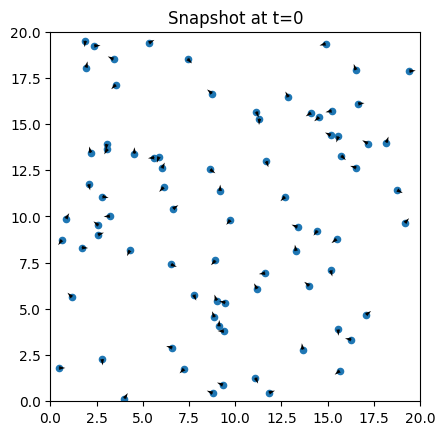

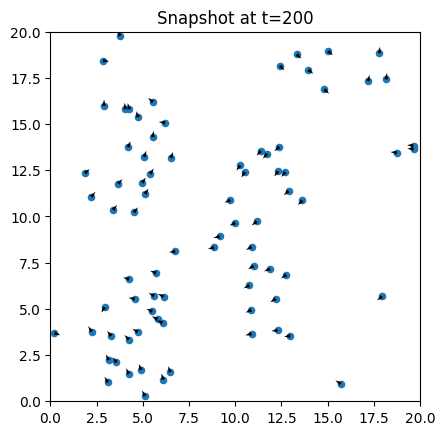

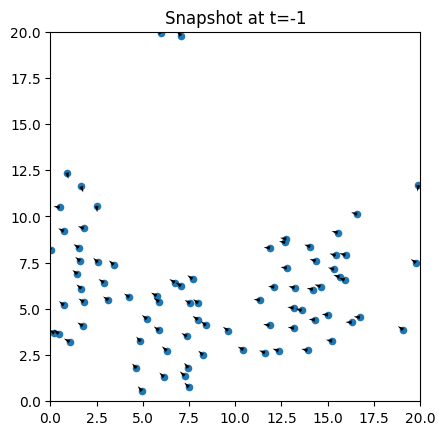

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def plot_snapshot(pos, theta, L, t=-1, arrow_scale=0.35, s=20):
    x = pos[t, :, 0]
    y = pos[t, :, 1]
    u = np.cos(theta[t])
    v = np.sin(theta[t])

    plt.figure()
    plt.scatter(x, y, s=s)
    plt.quiver(x, y, u, v, angles="xy", scale_units="xy", scale=1/arrow_scale)
    plt.xlim(0, L); plt.ylim(0, L)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.title(f"Snapshot at t={t}")
    plt.show()

plot_snapshot(pos, theta, L, t=0)
plot_snapshot(pos, theta, L, t=200)
plot_snapshot(pos, theta, L, t=-1)

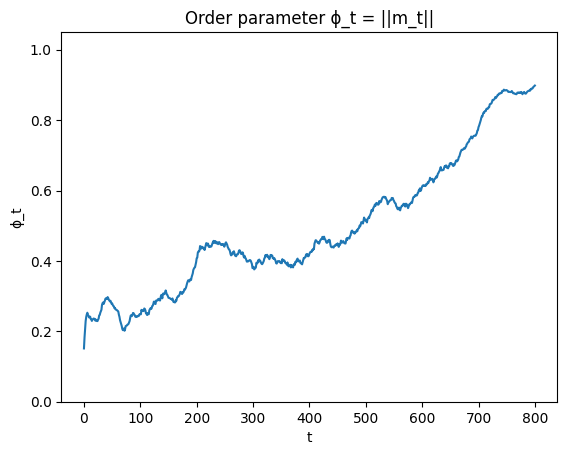

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

psi = np.linalg.norm(m_true, axis=1)

plt.figure()
plt.plot(psi)
plt.ylim(0, 1.05)
plt.title("Order parameter $\Psi_t = |\psi_t||$")
plt.xlabel("t")
plt.ylabel("Ψ_t")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def animate_flock(pos, theta, m_true, L, step=1, interval=30, s=18, show_arrows=True):
    """
    pos: (T+1, N, 2)
    theta: (T+1, N)
    m_true: (T+1, 2)
    L: box size
    step: show every 'step' frames
    interval: ms between frames
    show_arrows: if False, only scatter points
    """
    T = pos.shape[0] - 1
    frames = range(0, T + 1, step)

    fig, ax = plt.subplots()
    ax.set_xlim(0, L); ax.set_ylim(0, L)
    ax.set_aspect("equal", adjustable="box")

    # Initial frame
    x0 = pos[0, :, 0]; y0 = pos[0, :, 1]
    scat = ax.scatter(x0, y0, s=s)

    # Optional heading arrows
    quiv = None
    if show_arrows:
        u0 = np.cos(theta[0]); v0 = np.sin(theta[0])
        quiv = ax.quiver(x0, y0, u0, v0, angles="xy", scale_units="xy", scale=20)

    # Mean direction arrow from centre
    centre = np.array([L/2, L/2])
    mean_arrow = ax.quiver([centre[0]], [centre[1]],
                           [m_true[0, 0]], [m_true[0, 1]],
                           angles="xy", scale_units="xy", scale=2)

    txt = ax.text(0.02, 1.02, "", transform=ax.transAxes)

    def update(t):
        x = pos[t, :, 0]; y = pos[t, :, 1]
        scat.set_offsets(np.column_stack([x, y]))

        if show_arrows and quiv is not None:
            u = np.cos(theta[t]); v = np.sin(theta[t])
            quiv.set_offsets(np.column_stack([x, y]))
            quiv.set_UVC(u, v)

        mean_arrow.set_UVC([m_true[t, 0]], [m_true[t, 1]])

        phi = float(np.linalg.norm(m_true[t]))
        txt.set_text(f"t={t}   ϕ={phi:.3f}")
        return scat, mean_arrow, txt

    ani = FuncAnimation(fig, update, frames=frames, interval=interval, blit=False)
    plt.close(fig)  

    return ani

Here is a plot of the last K steps of the agents. In particular, we plot $ \{(x_i(t),y_i(t))\}_{t=T-K}^{T}$. In the below we use $K = 120$ and $T = 800$.

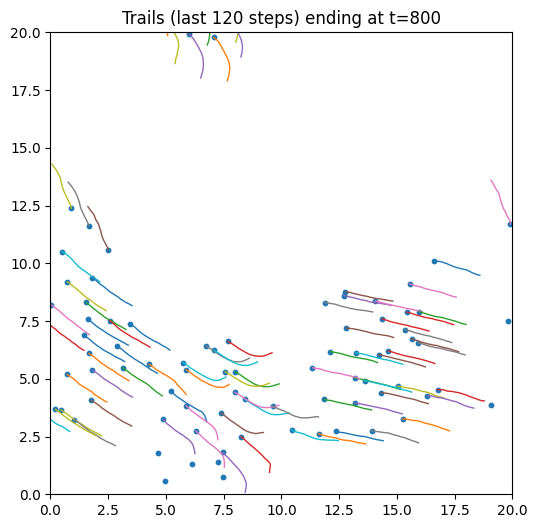

In [ ]:
def plot_trails(pos, theta, L, t_end=-1, K=80, s=10):
    t_end = (pos.shape[0] - 1) if t_end == -1 else t_end
    t0 = max(0, t_end - K)

    plt.figure(figsize=(6, 6))

    # plot trails for each agent
    for i in range(pos.shape[1]):
        #trajectory of agent i from t0 to t_end
        traj = pos[t0:t_end+1, i].copy()

        # unwrap periodic jumps
        for t in range(1, traj.shape[0]):
            #change in position from t-1 to t
            delta = traj[t] - traj[t-1]

            #wrap delta to [-L/2, L/2)
            delta[delta >  L/2] -= L
            delta[delta < -L/2] += L

            #unwrap position
            traj[t] = traj[t-1] + delta

        plt.plot(traj[:, 0], traj[:, 1], linewidth=1)

    # final positions at t_end
    plt.scatter(pos[t_end, :, 0], pos[t_end, :, 1], s=s)

    plt.xlim(0, L)
    plt.ylim(0, L)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.title(f"Trails (last {K} steps) ending at t={t_end}")
    plt.show()

plot_trails(pos, theta, L, K=120)